# 3.  Reason backwards 
1. Take the COVID-19 example from the lecture as a basis and implement a Python class that 
enables to reason from a single effect to the cause. Provide appropriate methods to input 
the required numbers. 
2. Play with the class, plot output for different combinations of inputs. 
3. Test the class for p(C)=0.2, P(L)=0.001, P(L|C)=0.01. What happened? Why? How to fix it?

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Class implementation

In [4]:
class Covid:
    def __init__(self, prob_cause=None, prob_effect=None, prob_effect_given_cause=None):
        self.prob_cause = prob_cause # P(C)
        self.prob_effect = prob_effect # P(E)
        self.prob_effect_given_cause = prob_effect_given_cause # P(E|C)
        
    def set_probabilities(self, prob_cause, prob_effect, prob_effect_given_cause):
        self.prob_cause = prob_cause
        self.prob_effect = prob_effect
        self.prob_effect_given_cause = prob_effect_given_cause
        
    def calculate_cause_given_effect(self):
        if self.prob_effect == 0:
            raise ValueError("0 in denominator :(")
        # P(C|E) = P(E|C)*P(C) / P(E) 
        return self.prob_effect_given_cause * self.prob_cause / self.prob_effect
    
    def display_results(self):
        print(f"P(Cause) = {self.prob_cause:.4f}")
        print(f"P(Effect) = {self.prob_effect:.4f}")
        print(f"P(Effect|Cause) = {self.prob_effect_given_cause:.4f}")
        
        result = self.calculate_cause_given_effect()
        if result is not None:
            print(f"P(Cause|Effect) = {result:.4f}")

In [40]:
covid = Covid()

prob_covid = 0.0062  # P(C)
prob_loss_smell = 0.01  # P(L)
prob_loss_given_covid = 0.9  # P(L|C)

covid.set_probabilities(prob_covid, prob_loss_smell, prob_loss_given_covid)
covid.display_results()

P(Cause) = 0.0062
P(Effect) = 0.0100
P(Effect|Cause) = 0.9000
P(Cause|Effect) = 0.5580


## 2. Play with the class, plot output for different combinations of inputs. 


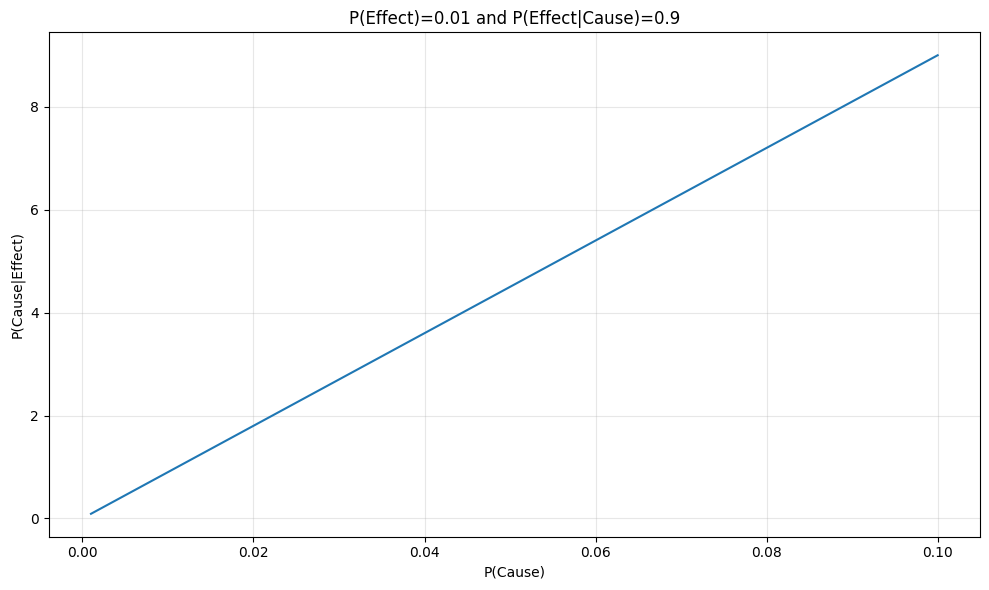

In [38]:
prob_cause_values = np.linspace(0.001, 0.1, 50)
prob_effect = 0.01
prob_effect_given_cause = 0.9

res = []
for p_c in prob_cause_values:
    covid = Covid(p_c, prob_effect, prob_effect_given_cause)
    res.append(covid.calculate_cause_given_effect())

plt.figure(figsize=(10, 6))
plt.plot(prob_cause_values, res)
plt.xlabel("P(Cause)")
plt.ylabel("P(Cause|Effect)")
plt.title("P(Effect)=0.01 and P(Effect|Cause)=0.9")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

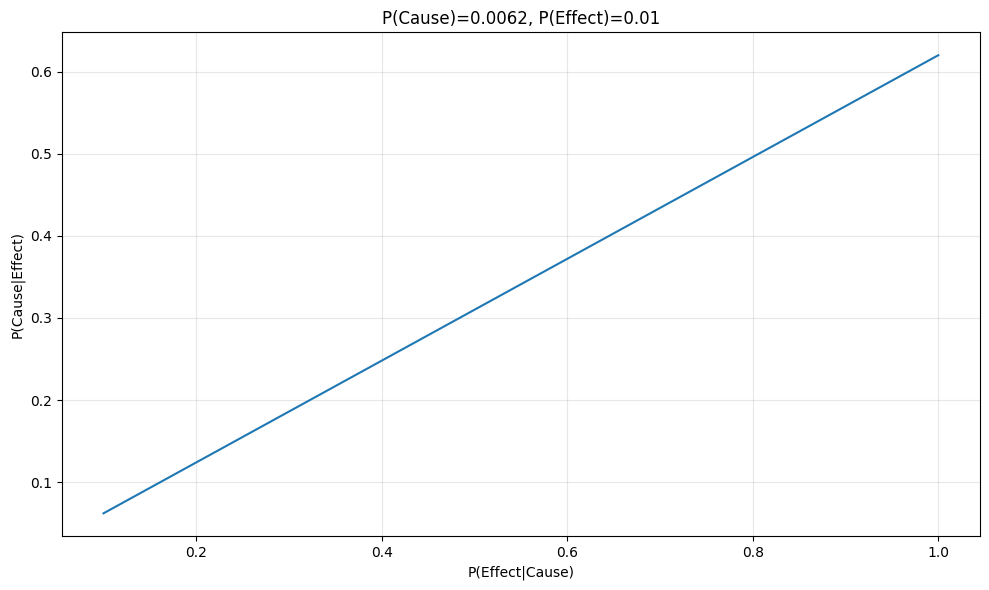

In [ ]:
prob_cause = 0.0062
prob_effect = 0.01
prob_effect_given_cause_values = np.linspace(0.1, 1.0, 50)

res = []
for p_e_given_c in prob_effect_given_cause_values:
    covid = Covid(prob_cause, prob_effect, p_e_given_c)
    res.append(covid.calculate_cause_given_effect())

plt.figure(figsize=(10, 6))
plt.plot(prob_effect_given_cause_values, res)
plt.xlabel("P(Effect|Cause)")
plt.ylabel("P(Cause|Effect)")
plt.title("P(Cause)=0.0062, P(Effect)=0.01")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Test the class for p(C)=0.2, P(L)=0.001, P(L|C)=0.01. What happened? Why? How to fix it?

In [33]:
test_case = Covid()
test_case.set_probabilities(0.2, 0.001, 0.01)
test_case.display_results()

P(Cause) = 0.2000
P(Effect) = 0.0010
P(Effect|Cause) = 0.0100
P(Cause|Effect) = 2.0000


### What happened, why?

Wynik to P(C|E) = 200%, co jest sprzeczne, ponieważ prawdopodobieństwo nie może przekraczać 100%.

Sprawdzmy prawdopodobieństwo osob, ktore maja covid i tracą węch:
P(C) * P(E|C) = 0.2 * 0.01 = 0.002

Z danych wejściowych wiemy, że całkowite prawdopodobieństwo utraty węchu wynosi: 0.001.

Patrząc na to jak na zbiory P(E ∩ C) <= P(E), z definicji prawdopodobieństwa warunkowego P(E ∩ C) = P(E|C) * P(C).

Zatem całkowite P(E) nie może być mniejsze niż 0.002. Przyjmując P(E) = 0.001, wychodzi sprzeczność, ponieważ podzbiór E ∩ C (osoby z covidem i utratą węchu) byłby większy niż zbiór E (wszyscy, którzy tracą węch).

**Podsumowując**

P(E) >= P(C) * P(E|C)

Jeśli ten warunek nie jest spełniony, oznacza to, że dane wejściowe nie mogą reprezentować rzeczywistego rozkładu prawdopodobieństwa.

### How to fix?

Wystarczy dodać walidację, która sprawdza czy powyższy warunek jest spełniony.

```
if self.prob_effect < self.prob_cause * self.prob_effect_given_cause:
```